In [17]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [19]:
# Configuration and paths
mac = 20
pheno_list = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list is None:
    pheno_list = pheno_config['biochemistry'] + pheno_config['overall_phenotype']
else:
    pheno_list = pheno_config[pheno_list]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['gpn_score', 'gpn_star_llr_calibrated_mean', 'cadd_raw']

# plof_cols = ['loftee_hc', 'loftee_lc']
# plof_cols = ['loftee_hc', 'loftee_lc', 'consequence_start_lost', 'consequence_stop_lost']

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno

encode_pels,id,encode_tf,encode_ca,encode_ca_ctcf,consequence_splice_donor_variant,non_mane_exonic,low_complexity_domain,five_prime_utr_variant_consequence_ustop_gained,gene_name,consequence_frameshift_variant,loftee_lc,encode_ca_tf,not_in_encode,mobi_lip_full,encode_dels,non_mane_cds,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,mobi_curated_disorder_priority,five_prime_utr_variant_consequence_ustop_lost,encode_pls,consequence_start_lost,mane_exonic,consequence_stop_gained,mane_cds,five_prime_utr_variant_consequence_uaug_lost,region,consequence_missense_variant,five_prime_utr_variant_consequence_uframeshift,ted_domain,consequence_stop_lost,encode_ca_h3k4me3,consequence_splice_acceptor_variant,start_stop_lost
bool,str,bool,bool,bool,i32,bool,bool,u8,str,i32,i8,bool,bool,bool,bool,bool,i8,u8,bool,u8,bool,i32,bool,i32,bool,u8,str,i32,u8,bool,i32,bool,i32,bool
false,"""chr15:64859998:G:C""",false,false,false,0,false,false,0,"""PLEKHO2""",0,0,false,false,true,true,false,0,0,false,0,false,0,true,0,true,0,"""ENSG00000241839""",1,0,false,0,false,0,false
false,"""chr1:202729885:A:T""",false,false,false,0,false,true,0,"""KDM5B""",0,0,false,true,true,false,false,0,0,true,0,false,0,true,0,true,0,"""ENSG00000117139""",1,0,false,0,false,0,false
false,"""chr11:125672628:A:G""",false,false,false,0,false,false,0,"""ACRV1""",0,0,false,true,false,false,false,0,0,false,0,false,0,true,0,true,0,"""ENSG00000134940""",1,0,true,0,false,0,false
false,"""chr1:202742800:C:T""",false,false,false,0,false,false,0,"""KDM5B""",0,0,false,false,false,true,false,0,0,false,0,false,0,true,0,true,0,"""ENSG00000117139""",1,0,false,0,false,0,false
false,"""chr1:202735550:A:G""",false,false,false,0,false,false,0,"""KDM5B""",0,0,false,true,false,false,false,0,0,true,0,false,0,true,0,true,0,"""ENSG00000117139""",1,0,false,0,false,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,"""chr1:32316756:C:CG""",false,false,false,0,false,false,0,"""HDAC1""",1,0,false,false,false,true,false,1,0,false,0,false,0,true,0,true,0,"""ENSG00000116478""",0,0,true,0,false,0,false
false,"""chr18:70020738:CAG:C""",false,false,false,0,false,false,0,"""RTTN""",1,0,false,true,false,false,false,1,0,false,0,false,0,true,0,true,0,"""ENSG00000176225""",0,0,false,0,false,0,false
false,"""chr22:28703536:CAAA:C""",false,false,false,0,false,false,0,"""CHEK2""",0,0,false,true,false,false,false,0,0,false,0,false,0,true,0,true,0,"""ENSG00000183765""",0,0,true,0,false,0,false


In [4]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['genomic_region']) # genomic_region
    pl.col('category').is_in(['plof_consequences']) # plof consequences

    # pl.col('category').is_in(['plof', 'missense']) # CDS
    # pl.col('category').is_in(['protein_domains']) # Protein Domains
    # pl.col('category').is_in(['loftee_protein_domains']) # LOFTEE Protein Domains

    # pl.col('category').is_in(['indel_cds']) # CDS indels
    # pl.col('category').is_in(['indel_length']) # indel length
    
    # pl.col('category').is_in(['encode_boolean']) # encode
    # pl.col('category').is_in(['encode_custom']) # encode custom regions
    # pl.col('category').is_in(['indel_categories', '5utr_annotator', 'encode_boolean']) # 5utr
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    .filter(
        (pl.col('annotation_score') != 0)
    )
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr9:132327226:C:CA""","""ENSG00000107290""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr13:32337521:CAAAAG:C""","""ENSG00000139618""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr6:56529767:TC:T""","""ENSG00000151914""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr22:41809990:G:GGCTCT""","""ENSG00000100147""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
"""chr22:36320834:A:AG""","""ENSG00000100345""","""consequence_frameshift_variant""",1.0,"""plof_consequences""",1,1.0
…,…,…,…,…,…,…
"""chr10:24584542:T:TG""","""ENSG00000107863""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0
"""chr4:105275611:A:ATG""","""ENSG00000168769""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0
"""chr4:105275569:CAG:C""","""ENSG00000168769""","""loftee_lc""",1.0,"""plof_consequences""",1,1.0


In [5]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [9]:
sorted(gene_trait_df['phenotype'].value_counts(sort=True)['phenotype'].to_list())

['alanine_aminotransferase_int',
 'albumin_int',
 'alkaline_phosphatase_int',
 'apolipoprotein_a_int',
 'apolipoprotein_b_int',
 'arm_fat_mass_left_int',
 'arm_fat_mass_right_int',
 'arm_fat_percentage_left_int',
 'arm_fat_percentage_right_int',
 'arm_fatfree_mass_left_int',
 'arm_fatfree_mass_right_int',
 'arm_predicted_mass_left_int',
 'arm_predicted_mass_right_int',
 'aspartate_aminotransferase_int',
 'basal_metabolic_rate_int',
 'birth_weight_int',
 'body_fat_percentage_int',
 'body_mass_index_bmi_int',
 'calcium_int',
 'cholesterol_int',
 'creactive_protein_int',
 'creatinine_int',
 'cystatin_c_int',
 'diastolic_blood_pressure_automated_reading_int',
 'direct_bilirubin_int',
 'eosinophill_count_int',
 'eosinophill_percentage_int',
 'fathers_age_at_death_int',
 'fluid_intelligence_score_int',
 'forced_expiratory_volume_in_1second_fev1_best_measure_int',
 'forced_expiratory_volume_in_1second_fev1_int',
 'forced_expiratory_volume_in_1second_fev1_predicted_int',
 'forced_expiratory_vo

In [ ]:
['alanine_aminotransferase_int',
 'albumin_int',
 'alkaline_phosphatase_int',
 'apolipoprotein_a_int',
 'apolipoprotein_b_int',
 'arm_fat_mass_left_int',
 'arm_fat_mass_right_int',
 'arm_fat_percentage_left_int',
 'arm_fat_percentage_right_int',
 'arm_fatfree_mass_left_int',
 'arm_fatfree_mass_right_int',
 'arm_predicted_mass_left_int',
 'arm_predicted_mass_right_int',
 'aspartate_aminotransferase_int',
 'basal_metabolic_rate_int',
 'birth_weight_int',
 'body_fat_percentage_int',
 'body_mass_index_bmi_int',
 'calcium_int',
 'cholesterol_int',
 'creactive_protein_int',
 'creatinine_int',
 'cystatin_c_int',
 'diastolic_blood_pressure_automated_reading_int',
 'direct_bilirubin_int',
 'eosinophill_count_int',
 'eosinophill_percentage_int',
 'fathers_age_at_death_int',
 'fluid_intelligence_score_int',
 'forced_expiratory_volume_in_1second_fev1_best_measure_int',
 'forced_expiratory_volume_in_1second_fev1_int',
 'forced_expiratory_volume_in_1second_fev1_predicted_int',
 'forced_expiratory_volume_in_1second_fev1_predicted_percentage_int',
 'forced_vital_capacity_fvc_best_measure_int',
 'forced_vital_capacity_fvc_int',
 'gamma_glutamyltransferase_int',
 'glucose_int',
 'glycated_haemoglobin_hba1c_int',
 'haematocrit_percentage_int',
 'haemoglobin_concentration_int',
 'hand_grip_strength_left_int',
 'hand_grip_strength_right_int',
 'hdl_cholesterol_int',
 'heel_bone_mineral_density_bmd_left_int',
 'heel_bone_mineral_density_bmd_right_int',
 'heel_bone_mineral_density_bmd_tscore_automated_int',
 'heel_bone_mineral_density_bmd_tscore_automated_left_int',
 'heel_bone_mineral_density_bmd_tscore_automated_right_int',
 'high_light_scatter_reticulocyte_count_int',
 'high_light_scatter_reticulocyte_percentage_int',
 'hip_circumference_int',
 'igf1_int',
 'immature_reticulocyte_fraction_int',
 'ldl_direct_int',
 'leg_fat_mass_left_int',
 'leg_fat_mass_right_int',
 'leg_fat_percentage_left_int',
 'leg_fat_percentage_right_int',
 'leg_fatfree_mass_left_int',
 'leg_fatfree_mass_right_int',
 'leg_predicted_mass_left_int',
 'leg_predicted_mass_right_int',
 'lipoprotein_a_int',
 'lymphocyte_count_int',
 'lymphocyte_percentage_int',
 'mean_corpuscular_haemoglobin_concentration_int',
 'mean_corpuscular_haemoglobin_int',
 'mean_corpuscular_volume_int',
 'mean_platelet_thrombocyte_volume_int',
 'mean_reticulocyte_volume_int',
 'mean_sphered_cell_volume_int',
 'mean_time_to_correctly_identify_matches_int',
 'microalbumin_in_urine_int',
 'monocyte_count_int',
 'monocyte_percentage_int',
 'mothers_age_at_death_int',
 'neutrophill_count_int',
 'neutrophill_percentage_int',
 'peak_expiratory_flow_pef_int',
 'phosphate_int',
 'platelet_count_int',
 'platelet_crit_int',
 'platelet_distribution_width_int',
 'pulse_rate_automated_reading_int',
 'pulse_rate_int',
 'red_blood_cell_erythrocyte_count_int',
 'red_blood_cell_erythrocyte_distribution_width_int',
 'reticulocyte_count_int',
 'reticulocyte_percentage_int',
 'seated_height_int',
 'shbg_int',
 'sitting_height_int',
 'standing_height_int',
 'systolic_blood_pressure_automated_reading_int',
 'testosterone_int',
 'total_bilirubin_int',
 'total_protein_int',
 'townsend_deprivation_index_at_recruitment_int',
 'triglycerides_int',
 'trunk_fat_mass_int',
 'trunk_fat_percentage_int',
 'trunk_fatfree_mass_int',
 'trunk_predicted_mass_int',
 'urate_int',
 'urea_int',
 'vitamin_d_int',
 'waist_circumference_int',
 'weight_int',
 'white_blood_cell_leukocyte_count_int',
 'whole_body_fat_mass_int',
 'whole_body_fatfree_mass_int',
 'whole_body_water_mass_int']

In [10]:
biochemistry = [
    'alanine_aminotransferase_int',
    'albumin_int',
    'alkaline_phosphatase_int',
    'apolipoprotein_a_int',
    'apolipoprotein_b_int',
    'aspartate_aminotransferase_int',
    'calcium_int',
    'cholesterol_int',
    'creactive_protein_int',
    'creatinine_int',
    'cystatin_c_int',
    'direct_bilirubin_int',
    'eosinophill_count_int',
    'eosinophill_percentage_int',
    'gamma_glutamyltransferase_int',
    'glucose_int',
    'glycated_haemoglobin_hba1c_int',
    'haematocrit_percentage_int',
    'haemoglobin_concentration_int',
    'hdl_cholesterol_int',
    'high_light_scatter_reticulocyte_count_int',
    'high_light_scatter_reticulocyte_percentage_int',
    'igf1_int',
    'immature_reticulocyte_fraction_int',
    'ldl_direct_int',
    'lipoprotein_a_int',
    'lymphocyte_count_int',
    'lymphocyte_percentage_int',
    'mean_corpuscular_haemoglobin_concentration_int',
    'mean_corpuscular_haemoglobin_int',
    'mean_corpuscular_volume_int',
    'mean_platelet_thrombocyte_volume_int',
    'mean_reticulocyte_volume_int',
    'mean_sphered_cell_volume_int',
    'microalbumin_in_urine_int',
    'monocyte_count_int',
    'monocyte_percentage_int',
    'neutrophill_count_int',
    'neutrophill_percentage_int',
    'phosphate_int',
    'platelet_count_int',
    'platelet_crit_int',
    'platelet_distribution_width_int',
    'red_blood_cell_erythrocyte_count_int',
    'red_blood_cell_erythrocyte_distribution_width_int',
    'reticulocyte_count_int',
    'reticulocyte_percentage_int',
    'shbg_int',
    'testosterone_int',
    'total_bilirubin_int',
    'total_protein_int',
    'triglycerides_int',
    'urate_int',
    'urea_int',
    'vitamin_d_int',
    'white_blood_cell_leukocyte_count_int'
]

overall_phenotype = [
    'arm_fat_mass_left_int',
    'arm_fat_mass_right_int',
    'arm_fat_percentage_left_int',
    'arm_fat_percentage_right_int',
    'arm_fatfree_mass_left_int',
    'arm_fatfree_mass_right_int',
    'arm_predicted_mass_left_int',
    'arm_predicted_mass_right_int',
    'basal_metabolic_rate_int',
    'birth_weight_int',
    'body_fat_percentage_int',
    'body_mass_index_bmi_int',
    'diastolic_blood_pressure_automated_reading_int',
    'fathers_age_at_death_int',
    'fluid_intelligence_score_int',
    'forced_expiratory_volume_in_1second_fev1_best_measure_int',
    'forced_expiratory_volume_in_1second_fev1_int',
    'forced_expiratory_volume_in_1second_fev1_predicted_int',
    'forced_expiratory_volume_in_1second_fev1_predicted_percentage_int',
    'forced_vital_capacity_fvc_best_measure_int',
    'forced_vital_capacity_fvc_int',
    'hand_grip_strength_left_int',
    'hand_grip_strength_right_int',
    'heel_bone_mineral_density_bmd_left_int',
    'heel_bone_mineral_density_bmd_right_int',
    'heel_bone_mineral_density_bmd_tscore_automated_int',
    'heel_bone_mineral_density_bmd_tscore_automated_left_int',
    'heel_bone_mineral_density_bmd_tscore_automated_right_int',
    'hip_circumference_int',
    'leg_fat_mass_left_int',
    'leg_fat_mass_right_int',
    'leg_fat_percentage_left_int',
    'leg_fat_percentage_right_int',
    'leg_fatfree_mass_left_int',
    'leg_fatfree_mass_right_int',
    'leg_predicted_mass_left_int',
    'leg_predicted_mass_right_int',
    'mean_time_to_correctly_identify_matches_int',
    'mothers_age_at_death_int',
    'peak_expiratory_flow_pef_int',
    'pulse_rate_automated_reading_int',
    'pulse_rate_int',
    'seated_height_int',
    'sitting_height_int',
    'standing_height_int',
    'systolic_blood_pressure_automated_reading_int',
    'townsend_deprivation_index_at_recruitment_int',
    'trunk_fat_mass_int',
    'trunk_fat_percentage_int',
    'trunk_fatfree_mass_int',
    'trunk_predicted_mass_int',
    'waist_circumference_int',
    'weight_int',
    'whole_body_fat_mass_int',
    'whole_body_fatfree_mass_int',
    'whole_body_water_mass_int'
]

In [15]:
len(biochemistry)

56

In [14]:
u = set(biochemistry).union(set(overall_phenotype))
len(u)

112

In [6]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [7]:
anno_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    
    # C. Group by annotation and aggregate
    .group_by(['annotation'])
    .agg(
        n_vars = pl.col('id').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )
    .with_columns(
        se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    )
    .collect(engine='streaming')
)

anno_pheno_df

annotation,n_vars,median_pheno,mean_pheno,std_pheno,se_pheno,ci_low_pheno,ci_high_pheno
str,u64,f64,f64,f64,f64,f64,f64
"""consequence_splice_donor_varia…",2298,0.269925,0.335231,0.800861,0.016706,0.302487,0.367976
"""consequence_stop_gained""",6157,0.309577,0.363417,0.828738,0.010562,0.342717,0.384118
"""consequence_start_lost""",336,0.173848,0.209961,0.703343,0.03837,0.134754,0.285167
"""consequence_frameshift_variant""",9561,0.263288,0.31925,0.85283,0.008722,0.302155,0.336345
"""consequence_stop_lost""",126,0.142572,0.178621,0.684608,0.06099,0.059081,0.298161
"""loftee_lc""",819,0.163905,0.211185,0.898156,0.031384,0.149672,0.272698
"""loftee_hc""",18857,0.287814,0.344137,0.831615,0.006056,0.332267,0.356007
"""consequence_splice_acceptor_va…",1804,0.305418,0.356108,0.790514,0.018612,0.319629,0.392587


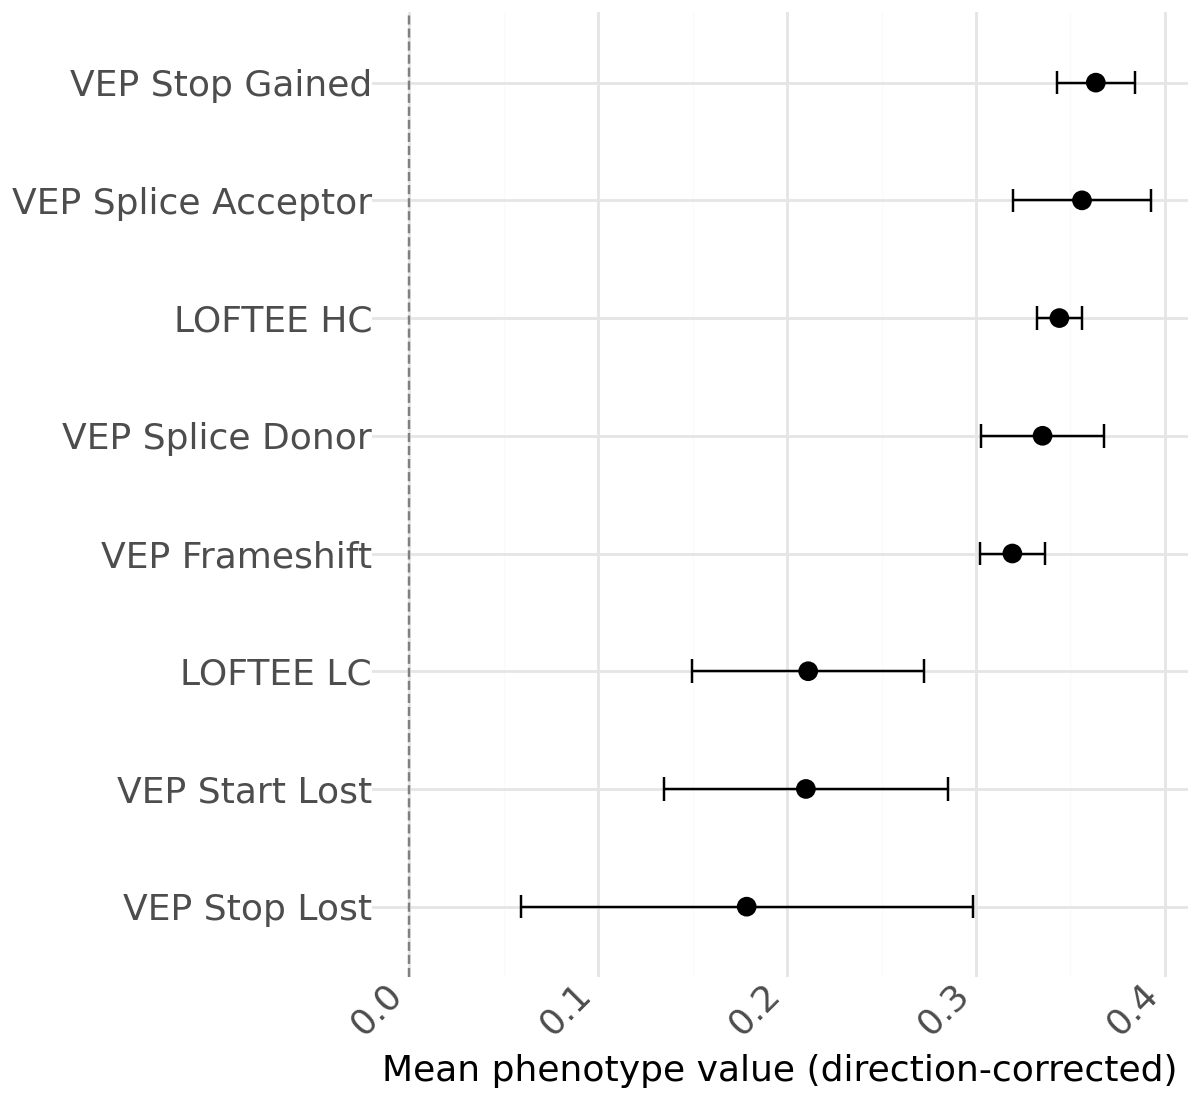

In [8]:
avg_plof_plot = (
    anno_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .to_pandas()
)

avg_plof_plot['label'] = pd.Categorical(
    avg_plof_plot['label'],
    categories=avg_plof_plot.sort_values('mean_pheno', ascending=True)['label'].unique(),
    ordered=True
)

(
    ggplot(
        avg_plof_plot,
        aes(x='label', y='mean_pheno')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        x='', 
        y='Mean phenotype value (direction-corrected)'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(6, 5.5),
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)